# Notebook 01: Initial Data Exploration

## Purpose

Perform systematic first-look analysis of the DataCo dataset. Goals:

1. Understand the shape and structure of the data
2. Identify data types, missing values, and duplicates
3. Spot obvious data quality issues
4. Document initial observations and hypotheses for deeper analysis

## Dataset

**DataCo Smart Supply Chain Dataset** — ~180K orders from 2015–2018, 53 columns covering orders, customers, products, shipping, and financials.

Source: [Mendeley Data](https://data.mendeley.com/datasets/8gx2fvg2k6/5)

## 1. Load Data


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings (cleaner output)
pd.set_option('display.max_columns', None)      # Show all columns
pd.set_option('display.width', 200)              # Wider console
pd.set_option('display.float_format', '{:,.2f}'.format)  # Format numbers

# Load the dataset
df = pd.read_csv(
    '../data/raw/DataCoSupplyChainDataset.csv',
    encoding='ISO-8859-1'
)

print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Loaded: 180,519 rows × 53 columns


## 2. Structure Overview
### First-Look Diagnostics

Running the "Data Detective" framework: shape, dtypes, nulls, duplicates, numerical and cateogrical analysis, outliers, summary stats.

In [30]:
# ============================================================
# FIRST-LOOK DIAGNOSTICS
# ============================================================

# 1. Shape
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# 2. Dtypes & non-null counts
df.info(verbose=True, show_counts=True)

Shape: 180,519 rows × 53 columns

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  str           
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  str           
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  str           
 9   Customer City                  180519 non-null  str           
 10  Customer Country               180519 non-nul

> **Quick observations:**
> - `Product Description` is **100% null** — column has no values at all
> - `Order Zipcode` has heavy nulls (only ~14% populated)
> - `order date (DateOrders)` is already datetime ✅ but `shipping date (DateOrders)` is still string — needs conversion
> - `Customer Zipcode` and `Customer Lname` have minor nulls

In [27]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,"95,125.00",2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,"90,027.00",2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


> Email, product Image and password columns need to be dropped

- Email and password columns are encrypted
- Date columns need to be split

### Missing Values

In [25]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


>- Last name -8
>- Customer Zipcode -3, 
>- Order Zipcode - 155679
>- Product Description - completely empty

### Duplicates Entries 

In [26]:
# ============================================================
# DUPLICATES
# ============================================================

print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Unique orders: {df['Order Id'].nunique():,}")
print(f"Total rows: {len(df):,}")
print(f"→ Avg items per order: {len(df) / df['Order Id'].nunique():.2f}\n")

# ============================================================
# DATE RANGE
# ============================================================

df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
print(f"Date range: {df['order date (DateOrders)'].min()} → {df['order date (DateOrders)'].max()}")
print(f"Years covered: {df['order date (DateOrders)'].dt.year.unique()}")

Duplicate rows: 0
Unique orders: 65,752
Total rows: 180,519
→ Avg items per order: 2.75

Date range: 2015-01-01 00:00:00 → 2018-01-31 23:38:00
Years covered: [2018 2016 2015 2017]


> There are no duplicate entries and the date ranges from 2015 to 2018

### Finding Primary Key

In [33]:
# Is Order Item Id unique?
print(f"Order Item Id unique: {df['Order Item Id'].is_unique}")
print(f"Total rows: {len(df):,}")
print(f"Unique Order Item Ids: {df['Order Item Id'].nunique():,}")

Order Item Id unique: True
Total rows: 180,519
Unique Order Item Ids: 180,519


> Order item id is the primary key of this table

In [ ]:
# ============================================================
# NUMERIC SUMMARY
# ============================================================

df.describe().T  

,count,mean,min,25%,50%,75%,max,std
Days for shipping (real),"180,519.00",3.50,0.00,2.00,3.00,5.00,6.00,1.62
Days for shipment (scheduled),"180,519.00",2.93,0.00,2.00,4.00,4.00,4.00,1.37
Benefit per order,"180,519.00",21.97,"-4,274.98",7.00,31.52,64.80,911.80,104.43
Sales per customer,"180,519.00",183.11,7.49,104.38,163.99,247.40,"1,939.99",120.04
Late_delivery_risk,"180,519.00",0.55,0.00,0.00,1.00,1.00,1.00,0.50
Category Id,"180,519.00",31.85,2.00,18.00,29.00,45.00,76.00,15.64
Customer Id,"180,519.00","6,691.38",1.00,"3,258.50","6,457.00","9,779.00","20,757.00","4,162.92"
Customer Zipcode,"180,516.00","35,921.13",603.00,725.00,"19,380.00","78,207.00","99,205.00","37,542.46"
Department Id,"180,519.00",5.44,2.00,4.00,5.00,7.00,12.00,1.63
Latitude,"180,519.00",29.72,-33.94,18.27,33.14,39.28,48.78,9.81


>- There are Huge losses, Need investivation on those
>

### Outlier Detection

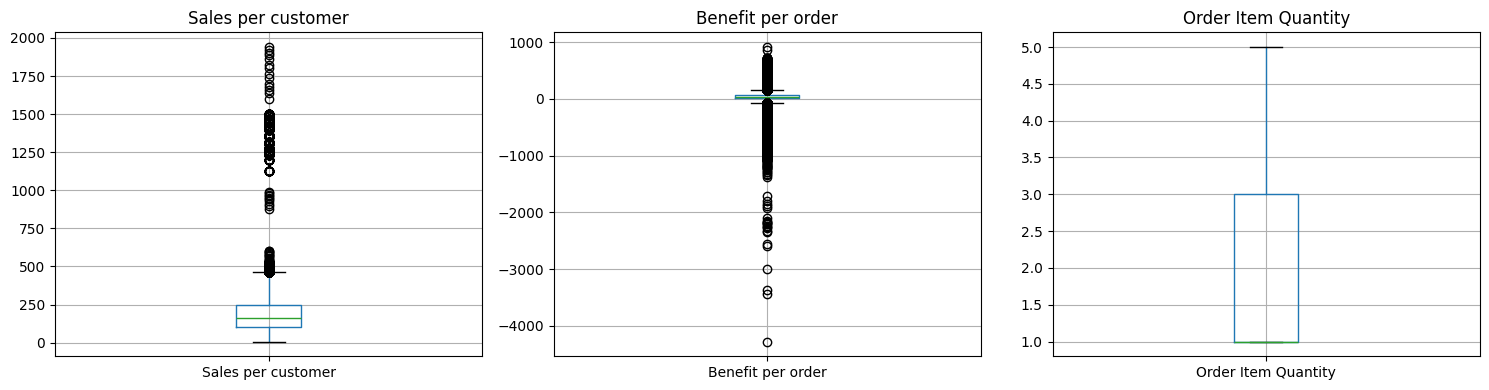

In [40]:
import matplotlib.pyplot as plt

cols_to_check = ['Sales per customer', 'Benefit per order', 'Order Item Quantity']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cols_to_check):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [41]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

for col in ['Sales per customer', 'Benefit per order']:
    count, low, high = count_outliers(df[col])
    print(f"{col}: {count:,} outliers (outside [{low:.2f}, {high:.2f}])")

Sales per customer: 1,943 outliers (outside [-110.15, 461.93])
Benefit per order: 18,942 outliers (outside [-79.70, 151.50])


In [44]:
# ============================================================
# FINANCIAL EXTREMES
# ============================================================

print("Benefit per order (Profit)")
print("=" * 60)
print(f"Min: ${df['Benefit per order'].min():,.2f}")
print(f"Max: ${df['Benefit per order'].max():,.2f}")
print(f"Mean: ${df['Benefit per order'].mean():,.2f}")
print(f"Negative (loss-making) orders: {(df['Benefit per order'] < 0).sum():,} "
      f"({(df['Benefit per order'] < 0).mean() * 100:.1f}%)\n")

print("Top 5 most profitable orders:")
print(df.nlargest(5, 'Benefit per order')[['Order Id', 'Category Name', 'Sales', 'Benefit per order']])

print("\nTop 5 worst loss-making orders:")
print(df.nsmallest(5, 'Benefit per order')[['Order Id', 'Category Name', 'Sales', 'Benefit per order']])

Benefit per order (Profit)
Min: $-4,274.98
Max: $911.80
Mean: $21.97
Negative (loss-making) orders: 33,784 (18.7%)

Top 5 most profitable orders:
        Order Id      Category Name    Sales  Benefit per order
175116     68883  Strength Training 1,999.99             911.80
48281      68821  Strength Training 1,999.99             864.00
82161      68724  Strength Training 1,999.99             721.60
43944      70558          Computers 1,500.00             720.30
58471      70668          Computers 1,500.00             720.00

Top 5 worst loss-making orders:
        Order Id      Category Name    Sales  Benefit per order
63990      68859  Strength Training 1,999.99          -4,274.98
169249     70533          Computers 1,500.00          -3,442.50
8259       74556          Computers 1,500.00          -3,366.00
126391     70760          Computers 1,500.00          -3,000.00
33845      74508          Computers 1,500.00          -2,592.00


> The extremes seem to provide some information about losses. The outliers will be kept as is for this analysis

In [42]:
# Verify  duplicate column hypothesis
pairs_to_check = [
    ('Benefit per order', 'Order Profit Per Order'),
    ('Product Card Id', 'Order Item Cardprod Id'),
    ('Category Id', 'Product Category Id'),
    ('Order Item Product Price', 'Product Price')
]

for col1, col2 in pairs_to_check:
    are_equal = df[col1].equals(df[col2])
    print(f"{col1} == {col2}: {are_equal}")

Benefit per order == Order Profit Per Order: True
Product Card Id == Order Item Cardprod Id: True
Category Id == Product Category Id: True
Order Item Product Price == Product Price: True


In [39]:
# Find highly correlated numeric columns (might be redundant)
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr().abs()

# Get upper triangle only (avoid duplicates in output)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find column pairs with >95% correlation
high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.95]

for col1, col2, corr in high_corr:
    print(f"{col1:35s} ↔ {col2:35s} corr: {corr:.4f}")

Order Customer Id                   ↔ Customer Id                         corr: 1.0000
Order Item Cardprod Id              ↔ Category Id                         corr: 0.9911
Order Item Id                       ↔ Order Id                            corr: 0.9996
Sales                               ↔ Sales per customer                  corr: 0.9897
Order Item Total                    ↔ Sales per customer                  corr: 1.0000
Order Item Total                    ↔ Sales                               corr: 0.9897
Order Profit Per Order              ↔ Benefit per order                   corr: 1.0000
Product Card Id                     ↔ Category Id                         corr: 0.9911
Product Card Id                     ↔ Order Item Cardprod Id              corr: 1.0000
Product Category Id                 ↔ Category Id                         corr: 1.0000
Product Category Id                 ↔ Order Item Cardprod Id              corr: 0.9911
Product Category Id                 ↔ Produ

In [43]:
# Your duplicate pairs from correlation output
pairs = [
    ('Order Customer Id', 'Customer Id'),
    ('Order Item Cardprod Id', 'Category Id'),
    ('Order Item Id', 'Order Id'),
    ('Sales', 'Sales per customer'),
    ('Order Item Total', 'Sales per customer'),
    ('Order Item Total', 'Sales'),
    ('Order Profit Per Order', 'Benefit per order'),
    ('Product Card Id', 'Category Id'),
    ('Product Card Id', 'Order Item Cardprod Id'),
    ('Product Category Id', 'Category Id'),
    ('Product Category Id', 'Order Item Cardprod Id'),
    ('Product Category Id', 'Product Card Id'),
    ('Product Price', 'Order Item Product Price'),
]

print(f"{'Column 1':<30} {'Column 2':<30} {'Identical?'}")
print("=" * 75)
for c1, c2 in pairs:
    identical = df[c1].equals(df[c2])
    marker = "✅" if identical else "❌"
    print(f"{c1:<30} {c2:<30} {marker} {identical}")

Column 1                       Column 2                       Identical?
Order Customer Id              Customer Id                    ✅ True
Order Item Cardprod Id         Category Id                    ❌ False
Order Item Id                  Order Id                       ❌ False
Sales                          Sales per customer             ❌ False
Order Item Total               Sales per customer             ✅ True
Order Item Total               Sales                          ❌ False
Order Profit Per Order         Benefit per order              ✅ True
Product Card Id                Category Id                    ❌ False
Product Card Id                Order Item Cardprod Id         ✅ True
Product Category Id            Category Id                    ✅ True
Product Category Id            Order Item Cardprod Id         ❌ False
Product Category Id            Product Card Id                ❌ False
Product Price                  Order Item Product Price       ✅ True


> Delete the columns which are exact duplicates of each other

In [37]:
# ============================================================
# DELIVERY STATUS — the heart of fulfillment analysis
# ============================================================

print("Delivery Status Distribution")
print("=" * 60)
print(df['Delivery Status'].value_counts())
print()
print("As %:")
print((df['Delivery Status'].value_counts(normalize=True) * 100).round(2))

# Double-check with Late_delivery_risk flag
print("\nLate_delivery_risk flag:")
print(df['Late_delivery_risk'].value_counts())

Delivery Status Distribution
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

As %:
Delivery Status
Late delivery       54.83
Advance shipping    23.04
Shipping on time    17.84
Shipping canceled    4.30
Name: proportion, dtype: float64

Late_delivery_risk flag:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


> 54% of all deliveries are late. Need to address the problem 

## 📋 Observations & Data Quality Findings

### Grain of the Data
- **1 row = 1 order line item** (not 1 order).
- 180,519 line items across 65,752 unique orders → avg **2.75 items per order**.
- **Primary key:** `Order Item Id` (verified unique and non-null).

### Structural Issues
- **Single flat table** — in a production system this would be normalized into ~6 tables (orders, customers, products, order_items, shipments, departments). Opportunity to demonstrate data modeling skills in SQL phase.
- **53 columns, many redundant** — reduced list in cleaning phase.

### Duplicate Columns (To Drop)
Verified using `.equals()` — these pairs contain identical values:

- ✂️ `Order Customer Id` → duplicate of `Customer Id`
- ✂️ `Order Item Total` → duplicate of `Sales per customer`
- ✂️ `Order Profit Per Order` → duplicate of `Benefit per order`
- ✂️ `Order Item Cardprod Id` → duplicate of `Product Card Id`
- ✂️ `Product Category Id` → duplicate of `Category Id`
- ✂️ `Order Item Product Price` → duplicate of `Product Price`

### Columns with No Analytical Value (To Drop)
- ✂️ `Product Description` — 100% null
- ✂️ `Product Image` — URL, not useful
- ✂️ `Customer Password` — anonymized
- ✂️ `Customer Email` — anonymized
- ✂️ `Customer Street`, `Customer Fname`, `Customer Lname` — anonymized as XXXXX

### Data Type Issues
- `shipping date (DateOrders)` is stored as string — needs conversion to datetime.
- `order date (DateOrders)` is already datetime ✅

### Completeness Issues
- `Order Zipcode` — heavily null (only ~14% populated); investigate whether to drop or keep.
- `Customer Zipcode`, `Customer Lname` — minor nulls; handle contextually.

### Fulfillment Red Flag 
- **54.83% of all deliveries are late** — the single biggest business issue in the data.
- `Late_delivery_risk` flag perfectly matches "Late delivery" count (98,977 each) — confirmed reliable indicator.

### Financial Concerns
- `Benefit per order` contains negative values — **18,942 orders (~10%) are loss-making**.
- Outliers exist (10% in Benefit per order, 1% in Sales) but are **kept intentionally** — they represent real business extremes, not data errors.
- `Sales` vs `Sales per customer` differ by discount amount — opportunity to analyze discount impact on margin.

### Date Range
- Data covers **2015-01-01 to 2018-01-31** (3 years, 1 month).

### Next Steps (Notebook 02: Cleaning)
1. Drop duplicate columns (6 pairs)
2. Drop no-value columns (9 columns: Product Description, Image, PII, etc.)
3. Convert `shipping date (DateOrders)` to datetime
4. Handle remaining nulls (contextual per column)
5. Rename all columns to `snake_case` for easier SQL/pandas querying
6. Save cleaned dataset to `data/processed/dataco_cleaned.csv`